# Temperature Correlations and Kriging

## Load in calibrator data

In [1]:
from importlib import reload
try:
    reload(kriging_modified)
    from kriging import Kriging
except:
    import kriging
    reload(kriging)
    from kriging import Kriging
import numpy as np
import matplotlib.pyplot as plt

import time

In [2]:
freqarr, freqstep = np.linspace(0,250,4096,retstep=True) # Based on number of frequency channels of the antenna
minfreq = 100
# maxfreq = 
minfreqarg = int(minfreq/freqstep)
maxfreqarg = minfreqarg
# print(freqstep)
# print(freqarr[minfreqarg:maxfreqarg])
# freq = 100 # MHz
# freq_index = int(freq/freqstep)
freq=minfreq
freq_index = minfreqarg
print(freq_index)

1638


### Saving other 2021 100NS calibrator masks

Turns out I haven't flagged any of the 50Ohm or 100Ohm so we'll just load them in without a mask (the saved mask is all True anyway).

In [3]:
# Saving other calibrator masks
import data_prep
reload(data_prep)
from data_prep import DataPrep

year = '2021'
instrument = '100MHz'
channel = 'NS'

datadir = '../test_data/'+year+'/'+instrument+'/'+channel+'/'

# dataprep = DataPrep(instrument, channel, year)
# save_mask_100 = copy.deepcopy(dataprep.calib_mask_dict['res100']) # save the mask
# save_mask_50 = copy.deepcopy(dataprep.calib_mask_dict['res50']) # save the mask

# np.save(datadir+'res100data_2021_100MHz_NS_mask.npy',dataprep.calib_mask_dict['res100'])
# np.save(datadir+'res50data_2021_100MHz_NS_mask.npy',dataprep.calib_mask_dict['res50'])

TypeError: object of type 'NoneType' has no len()

### Loading in pre-saved data

In [3]:
# Load in the data
year = '2021'
instrument = '100MHz'
channel = 'NS'

datadir = '../test_data/'+year+'/'+instrument+'/'+channel+'/'

# Antenna
save_mask = np.load(datadir+'shortdata_'+year+'_'+instrument+'_'+channel+'_mask.npy')
print(np.sum(save_mask)/len(save_mask)*100,'%') # prints percentage of UNFLAGGED spectra
t_ant = np.load(datadir+'antsystime_'+year+'_'+instrument+'_'+channel+'.npy')

# Masked SHORT data
dat=np.load(datadir+'shortdata_meas_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]
lst=np.load(datadir+'shortlst_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]
t=np.load(datadir+'shortsystime_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]
# Unmasked data
# dat=np.load(datadir+'shortdata_meas_'+year+'_'+instrument+'_'+channel+'.npy')
# lst=np.load(datadir+'shortlst_'+year+'_'+instrument+'_'+channel+'.npy')
# t=np.load(datadir+'shortsystime_'+year+'_'+instrument+'_'+channel+'.npy')

# Masked 50 OHM data
save_mask_50 = np.load(datadir+'res50data_'+year+'_'+instrument+'_'+channel+'_mask.npy')
print(np.sum(save_mask_50)/len(save_mask_50)*100,'%') # prints percentage of UNFLAGGED spectra
dat_50=np.load(datadir+'res50data_meas_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask_50]
lst_50=np.load(datadir+'res50lst_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask_50]
t_50=np.load(datadir+'res50systime_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask_50]

# Masked 100 OHM data
save_mask_100 = np.load(datadir+'res100data_'+year+'_'+instrument+'_'+channel+'_mask.npy')
print(np.sum(save_mask_100)/len(save_mask_100)*100,'%') # prints percentage of UNFLAGGED spectra
dat_100=np.load(datadir+'res100data_meas_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask_100]
lst_100=np.load(datadir+'res100lst_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask_100]
t_100=np.load(datadir+'res100systime_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask_100]

82.08322950411163 %
100.0 %
100.0 %


### Practicing some RFI flagging

In [66]:
# Practicing some RFI flagging
import rfi_flagging
reload(rfi_flagging)
from rfi_flagging import RFI_flagging

In [67]:
rfi_obj = RFI_flagging(data=dat,freq=freqarr,lst=lst,systime=t)

In [68]:
# rfi_obj.truncate(highpass=50,lowpass=200)

In [69]:
#rfi_obj.lst_flagging(binsize=60,threshold=3) # there is an isse with the lst_flagging algo

In [ ]:
rfi_obj.spectral_flagging(window=10,thresh=3)

(3294, 4096)
(4086, 3294, 11)
(4086, 3294)
(4086, 3294, 11)
(4086, 3294, 10)


### Select a subset of the data

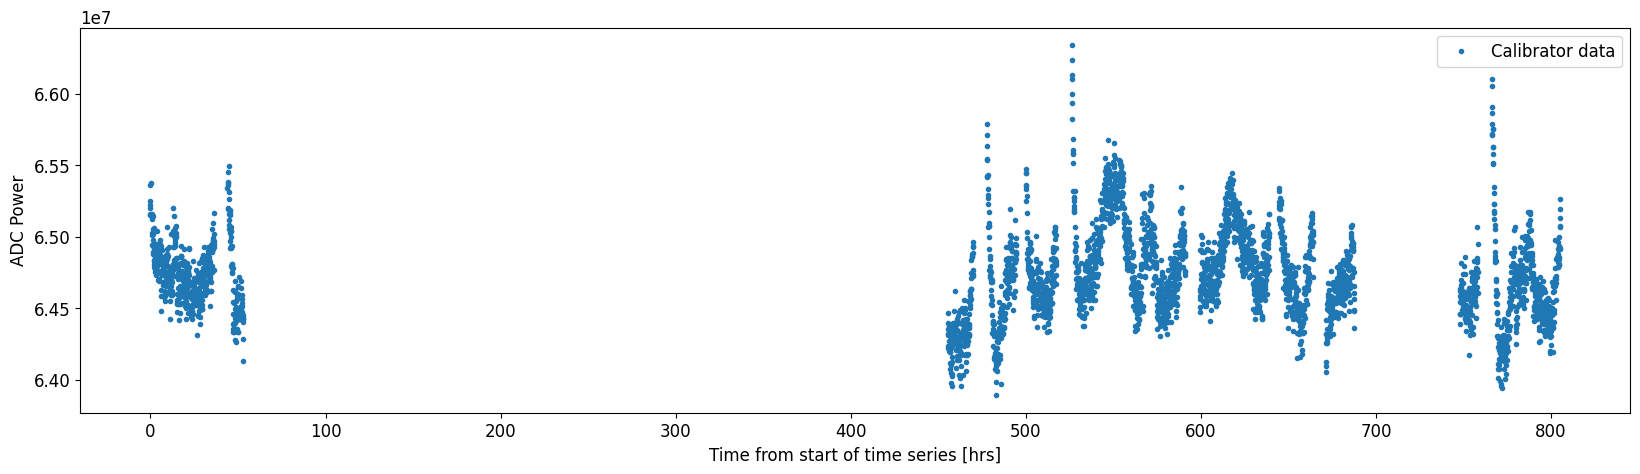

In [4]:
# Optional: select a subset of the data (mostly for testing)
# tmax=1.6374e9
# tmin=1.6365e9
# tmax=1.6377e9
tmax=np.inf
tmin=0

mask=(t>tmin)&(t<tmax)
tt=t[mask]
dd=dat[mask,:]

ant_mask = (t_ant>tmin)&(t_ant<tmax)
tt_ant = t_ant[ant_mask]

# Pick a freq_index to plot (the fit is done for all frequencies)
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(20,5))
# plt.plot((tt-tt[0])/3600,dd[:,freq_index],'.',label='Calibrator data')
plt.plot((tt-tt[0])/3600,dd[:,freq_index],'.',label='Calibrator data')
# plt.plot((tt_ant-tt[0])/3600,[6.5e7 for ti in tt_ant],'.',color='red',label='Antenna times')
# plt.title('Short Calibrator Data and Antenna Times To Interpolate To\nFrequency Channel = '+str(freq)+'MHz')
# plt.xlim(left=-40,right=60)
# plt.xlim(left=450)
plt.xlabel('Time from start of time series [hrs]')
plt.ylabel('ADC Power')
plt.legend(loc='upper right')
plt.savefig('PreInterp5.png',bbox_inches='tight',dpi=300)
plt.show()

## Short Power - Temperature Correlations

In [5]:
import sys
from importlib import reload
reload(sys)
import sys

# sys.path.remove("/home/s/sievers/lauriea/prizm-data-wrangling/prizmdatawrangling")
# sys.path

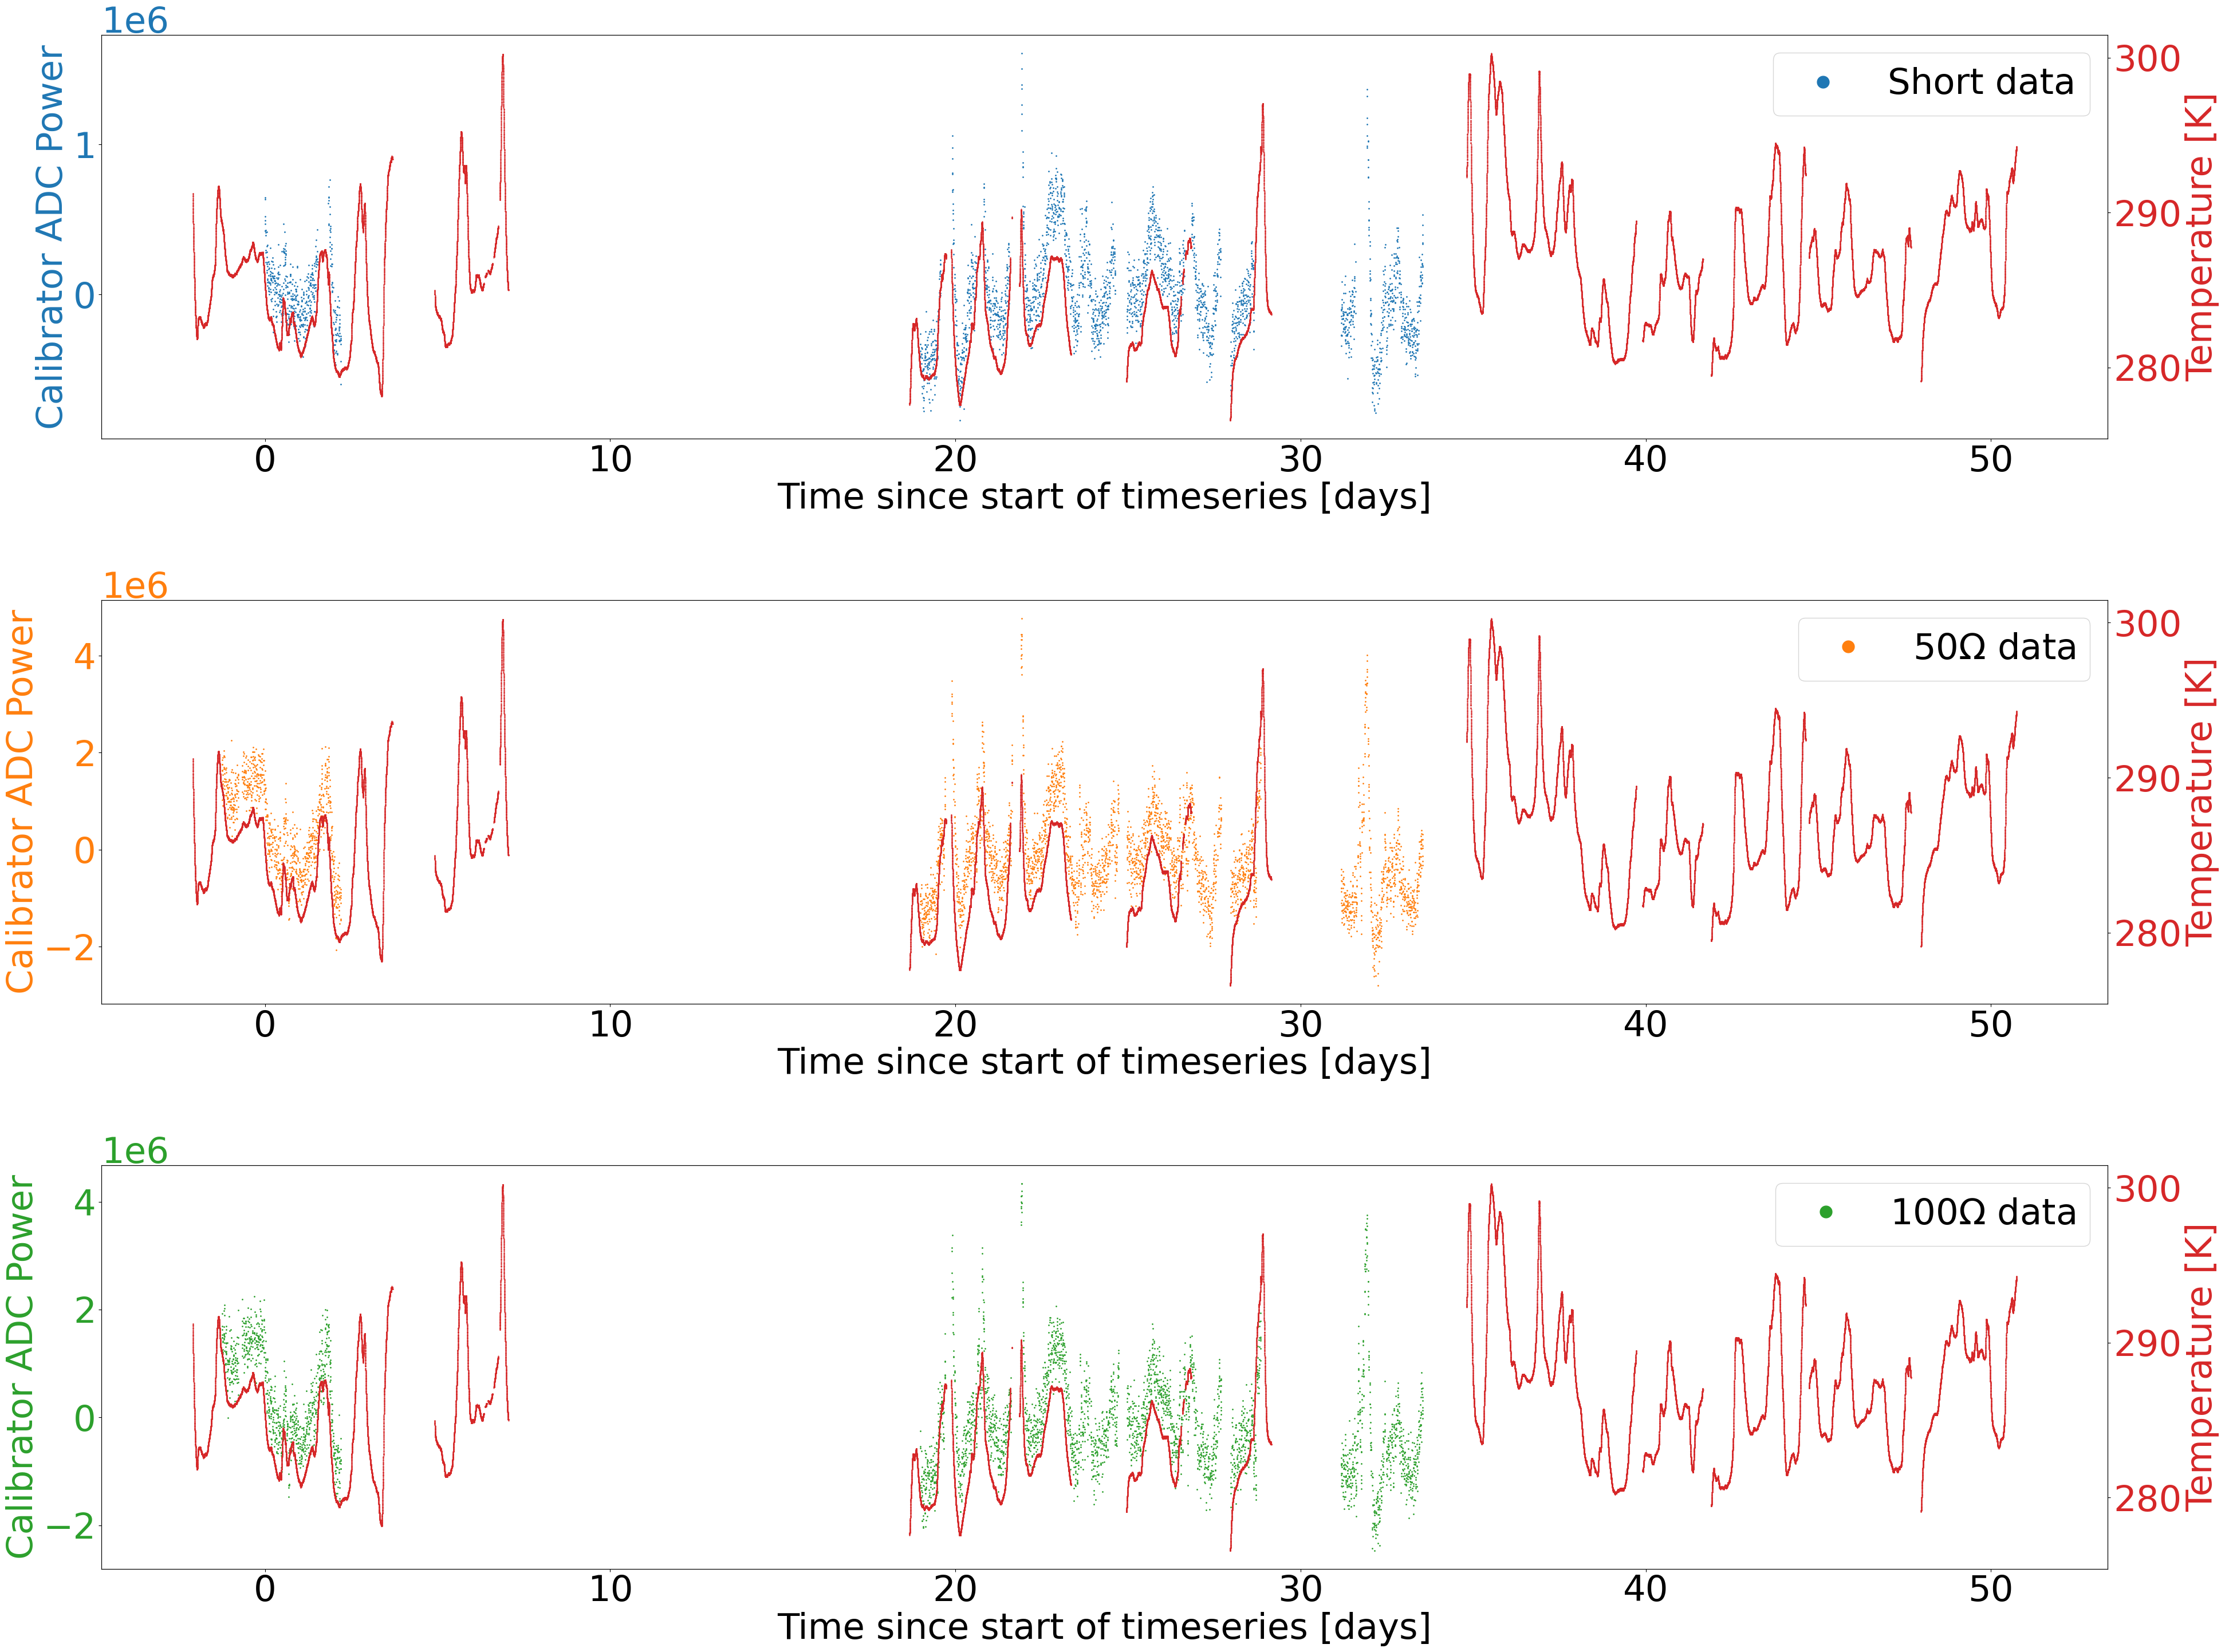

In [43]:
# Importing system temperature to check correlations between temperature variations and calibrator power variations
from data import get_temperatures, interpolate_temperature

# path to temperature directories (2021 only)
plt.rcParams.update({'font.size': 45})
path2dir = f'/project/s/sievers/prizm/marion2022/prizm-{instrument[:-3]}/data_{instrument}/temperatures'
# temp_type = 'ambient'
# T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
# T_amb, systime_amb, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, tt)
temp_type = '100NS_switch'
T_switch = get_temperatures(instrument, path2dir, temp_type=temp_type)
# T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, tt)
systime_switch = (T_switch['time_sys_start'] + T_switch['time_sys_stop']) / 2

# -------------------------------------------
fig, ax1 = plt.subplots(nrows=3,ncols=1,figsize=(40,30))

# short plot
ax1[0].set_xlabel('Time since start of timeseries [days]')
ax1[0].set_ylabel('Calibrator ADC Power',color='tab:blue')
# ax1.plot(t, data1, color=color)
ax1[0].plot((tt-tt[0])/3600/24,dd[:,freq_index]-dd[:,freq_index].mean(),color='tab:blue',label='Short data',ms=2,marker='.',ls='None')
ax1[0].tick_params(axis='y', labelcolor='tab:blue')
ax1[0].legend(markerscale=15)

ax2 = ax1[0].twinx()  # instantiate a second Axes that shares the same x-axis
# color = 'tab:red'
ax2.set_ylabel('Temperature [K]', color='tab:red')  # we already handled the x-label with ax1
ax2.plot((systime_switch-tt[0])/3600/24, T_switch[f'temp_{temp_type}'], color='tab:red',ms=1,ls='none',marker='.',label='100NS_switch')
ax2.tick_params(axis='y', labelcolor='tab:red')
# ax2.legend(markerscale=3,fontsize='medium')

# 50 Ohm plot
ax1[1].set_xlabel('Time since start of timeseries [days]')
ax1[1].set_ylabel('Calibrator ADC Power',color='tab:orange')
ax1[1].plot((t_50-tt[0])/3600/24,dat_50[:,freq_index]-dat_50[:,freq_index].mean(),color='tab:orange',label=r'$50\Omega$ data',ms=2,marker='.',ls='None')
ax1[1].tick_params(axis='y', labelcolor='tab:orange')
ax1[1].legend(markerscale=15)

ax2 = ax1[1].twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('Temperature [K]', color='tab:red')  # we already handled the x-label with ax1
ax2.plot((systime_switch-tt[0])/3600/24, T_switch[f'temp_{temp_type}'], color='tab:red',ms=1,ls='none',marker='.',label='100NS_switch')
ax2.tick_params(axis='y', labelcolor='tab:red')
# ax2.legend(markerscale=3,fontsize='medium')

# 100 Ohm plot
ax1[2].set_xlabel('Time since start of timeseries [days]')
ax1[2].set_ylabel('Calibrator ADC Power',color='tab:green')
ax1[2].plot((t_100-tt[0])/3600/24,dat_100[:,freq_index]-dat_100[:,freq_index].mean(),color='tab:green', label=r'$100\Omega$ data',ms=2,marker='.',ls='None')
ax1[2].tick_params(axis='y', labelcolor='tab:green')
ax1[2].legend(markerscale=15)

ax2 = ax1[2].twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('Temperature [K]', color='tab:red')  # we already handled the x-label with ax1
ax2.plot((systime_switch-tt[0])/3600/24, T_switch[f'temp_{temp_type}'], color='tab:red',ms=1,ls='none',marker='.',label='100NS_switch')
ax2.tick_params(axis='y', labelcolor='tab:red')
# ax2.legend(markerscale=3,fontsize='medium')

# plt.xlim(20,20.2)
# plt.title('Short Calibrator Data\nFrequency Channel = '+str(freq)+'MHz\nComparison to 100NS Switch Temperature')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.subplots_adjust(hspace=0.4)
# plt.savefig('allcalib_and_temp_subplots.jpg',dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
# Estimating the sampling rate of temperature
# np.median(np.diff(systime_switch))

# Figuring out the typical spacing between temp measurements
plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(10,1))
ax.vlines((systime_switch-tt[0])/3600,color='lightblue',ymin=0,ymax=1) # in hours
ax.set_xlabel('Time since start of time series [hrs]')
ax.set_ylabel('Arbitrary')
ax.set_title('Times where short power data is taken')
ax.set_ylim(0,1)
plt.show()

# Make a histogram since this plot is telling us nothing useful about short term variations
temptdiffs = np.diff(systime_switch)/60 # in mins
n, bins, _ = plt.hist(temptdiffs,bins=np.logspace(-1.5,5,100),log=True)
# plt.yscale('log')
plt.xscale('log')
plt.title(f'Time separation between consecutive short power measurements\nN_samples = {len(temptdiffs)}')
plt.xlabel('Time separation [mins]')
plt.ylabel('Counts')
plt.grid()
plt.show()

In [44]:
print(bins[np.argmax(n)]*60)
print(len(systime_switch))

6.359218913295012
134356


In [7]:
# Plot all temperatures, no interpolation
temp_type = ['ambient','100NS_bot_lna','100NS_top_lna','100NS_switch','100NS_noise']

plt.rcParams.update({'font.size': 15})
fig, axs = plt.subplots(nrows=2,ncols=1,sharex=True,figsize=(20,10),dpi=600)
for i in range(len(temp_type)):
    
    T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type[i])
    temp_time = (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2
    
    #plt.plot((temp_time - temp_time[0]) /3600/24, T_phys[f'temp_{temp_type[i]}'],'.',ms=1,label=temp_type[i])
    axs[0].plot((temp_time-tt[0])/3600/24, T_phys[f'temp_{temp_type[i]}'],'.',ms=1,label=temp_type[i])
    #if i == 0: break # testing
        
axs[1].plot((tt-tt[0])/3600/24,dd[:,freq_index],'.',ms=2,label='Calibrator data',color='k')

axs[0].legend(fontsize='small',markerscale=6,ncols=2,loc='upper right')
axs[0].grid('on')
axs[1].grid('on')
axs[0].set_ylim(top=310,bottom=270)
axs[1].set_xlabel('Time since start of time series [days]')
# axs[1].set_xlabel('UNIX Timestamp [s]')
axs[0].set_ylabel('Temperature [K]')
axs[1].set_ylabel('ADC Power')
axs[1].legend(fontsize='small',markerscale=3,loc='upper right')
# axs[0].set_xlim(left=1.6365e9,right=1.638e9)
# axs[0].set_xlim(left=17,right=34)
plt.show()

In [ ]:
# WIP

### Making Autocorrelation Function of Short Power vs. Temperature Separation

So apparently this is the __wrong way to do it__, and Mohan, Jon and Cynthia say what I should be computing is the cross-correlation of the short power timestream and the temperature timestream instead of the "auto"correlation of the two datasets interpolated to be at the same times.

In [15]:
from test_short_interp import make_acf # import ACF computing function (normally same one that is in kriging.py)

In [16]:
# Get 'switch' temperature data and interpolate it to the short data times
temp_type = '100NS_switch'
T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, tt)

dt = 0.5
tmax = 25
tot, wt = make_acf(dat=dd[interp_inds,freq_index]-dd[interp_inds,freq_index].mean(),t=T_switch,dt=dt,tmax=tmax) # dd set to 100MHz freq channel right now, dt = 1 K, tmax = 25 K

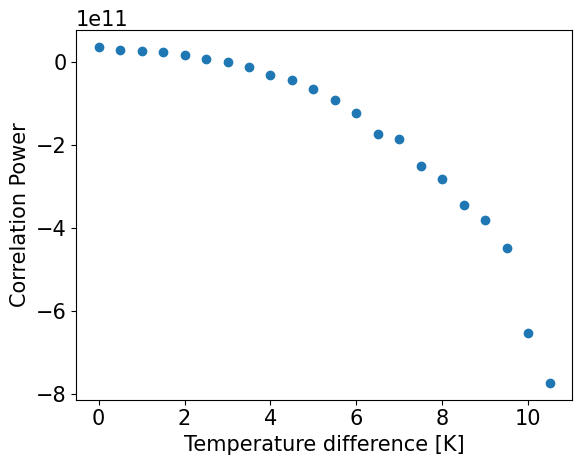

In [11]:
mm = wt > 0 # weight criterion
temp_vec = np.arange(len(tot))[mm]*dt
plt.plot(temp_vec,tot[mm]/wt[mm],'o')
plt.xlabel('Temperature difference [K]')
plt.ylabel('Correlation Power')
plt.show()

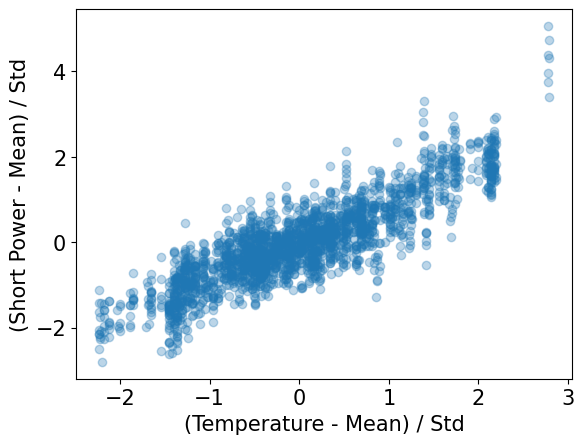

In [12]:
# Simple plot of short power vs. temperature
plt.plot((T_switch-T_switch.mean())/np.std(T_switch),(dd[interp_inds,freq_index]-dd[interp_inds,freq_index].mean())/np.std(dd[interp_inds,freq_index]),'o',alpha=0.3)
plt.xlabel('(Temperature - Mean) / Std',fontsize=15)
plt.ylabel('(Short Power - Mean) / Std',fontsize=15)
plt.show()

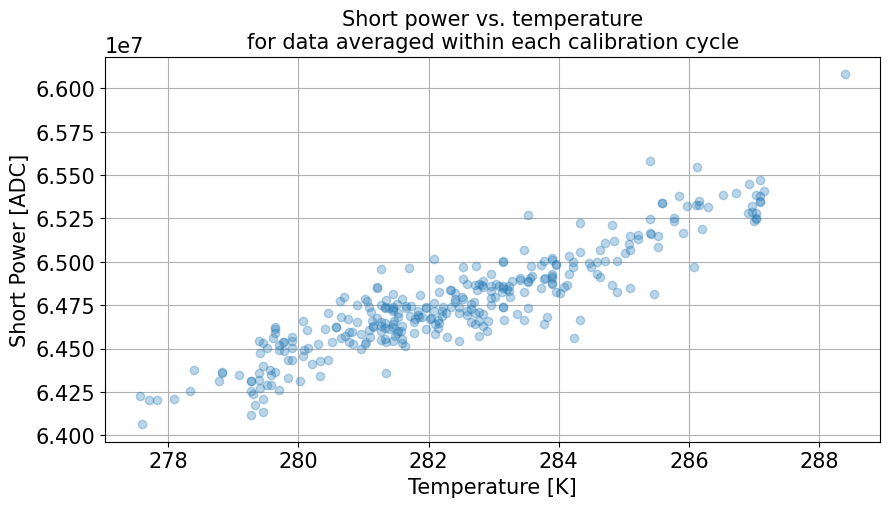

In [53]:
# Same plot but with averaging within each calibration cycle

from kriging import Kriging
# Initialize Kriging class
krig_object = Kriging(systime=tt,data=dd,interp_times=t_ant,tmax_mask=np.nan,tmin_mask=np.nan,
                 minfreq=None,maxfreq=None,minfreqarg=freq_index,maxfreqarg=freq_index)

# Use smooth_acf to average the values
avgd_times, avgd_data, avgd_std = krig_object.smooth_acf(tvec=tt,acf=dd[:,freq_index],cycle_jump=5*60,isACF=False)
# syntax: smooth_acf(self,tvec,acf,cycle_jump=60,isACF=False)

# Plot averaged values
# plt.figure(figsize=(20,5))
# plt.scatter(avgd_times,avgd_data,marker='.')
# plt.show()

# Interpolate temperatures to the averaged times
T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, avgd_times)

# Make short power vs. temperature scatterplot
plt.figure(figsize=(10,5))
plt.plot(T_switch,avgd_data[interp_inds],'o',alpha=0.3)
plt.xlabel('Temperature [K]',fontsize=15)
plt.ylabel('Short Power [ADC]',fontsize=15)
plt.title('Short power vs. temperature\nfor data averaged within each calibration cycle',fontsize=15)
plt.grid()
plt.show()

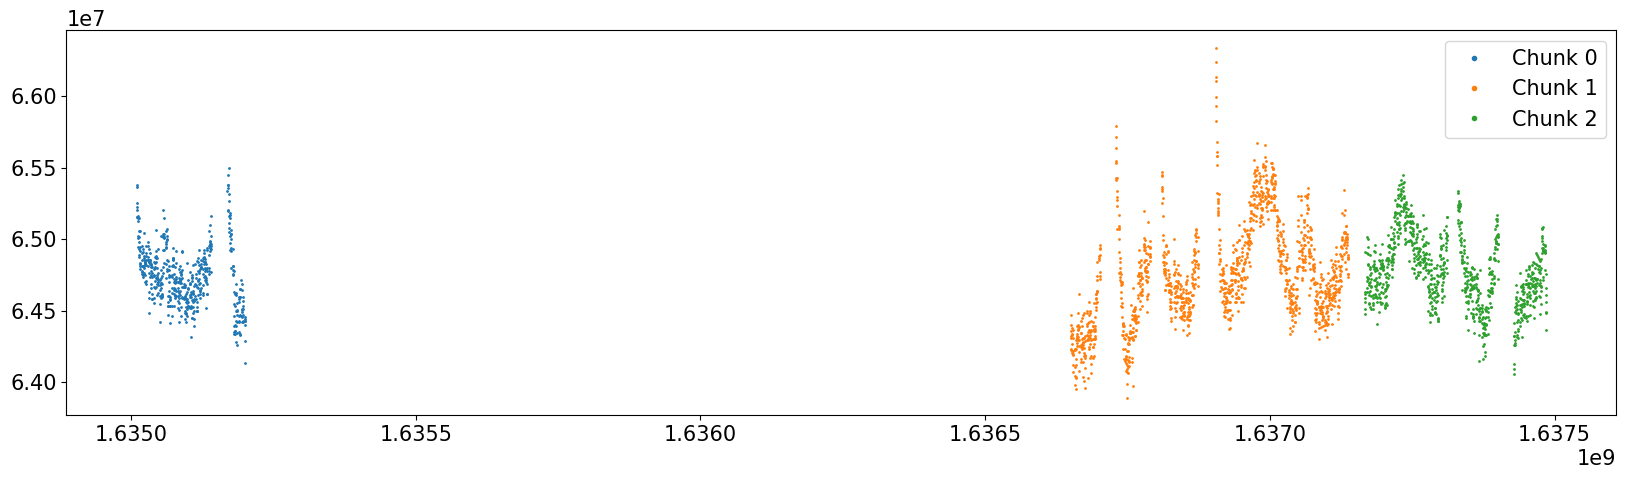

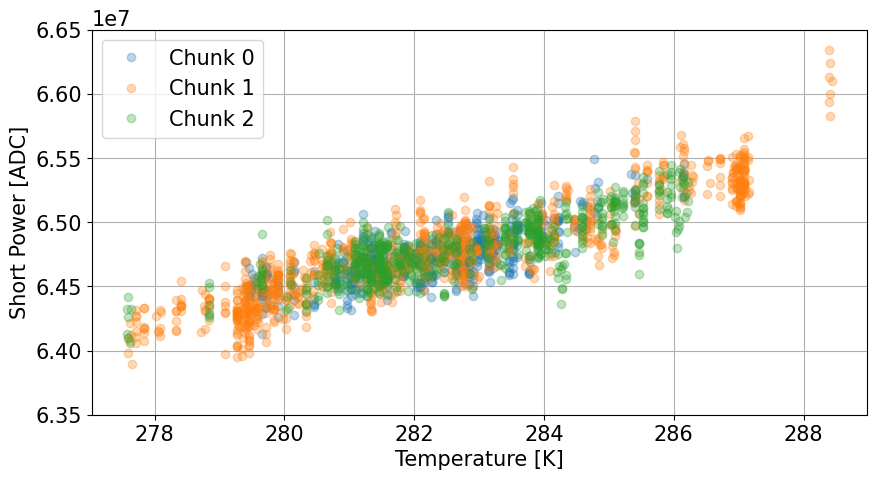

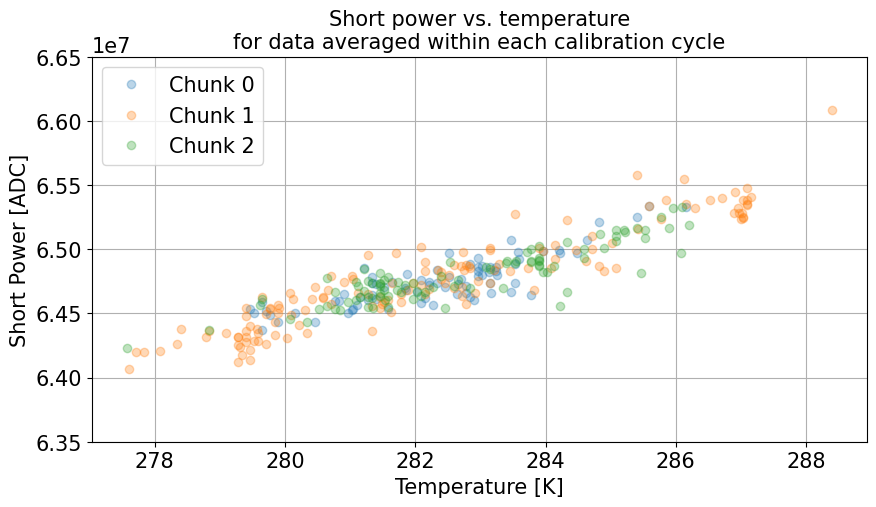

In [57]:
# Same plot of short power vs. temperature for 3 different chunks
temp_type = '100NS_switch'
T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
time_stops = np.array([0,1.6365e9,1.63715e9,1.6376e9])

# Plot the 3 different chunks
plt.figure(figsize=(20,5))
for i in range(3):
    time_rng = tt[(tt>time_stops[i]) & (tt<time_stops[i+1])]
    dat_rng = dd[(tt>time_stops[i]) & (tt<time_stops[i+1]),freq_index]
    plt.plot(time_rng,dat_rng,label='Chunk '+str(i),marker='.',ms=2,ls='none')

plt.legend(markerscale=3)
plt.show()




# Plot short power vs. temperature scatterplot
plt.figure(figsize=(10,5))
for i in range(3):
    try:
        time_rng = tt[(tt>time_stops[i]) & (tt<time_stops[i+1])]
        dat_rng = dd[(tt>time_stops[i]) & (tt<time_stops[i+1]),:]
        T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, time_rng)
    except:
        break
    
    plt.plot(T_switch,dat_rng[interp_inds,freq_index],'o',alpha=0.3,label='Chunk '+str(i))


plt.ylim(top=6.65e7,bottom=6.35e7)
plt.xlabel('Temperature [K]')
plt.ylabel('Short Power [ADC]')
plt.grid()
plt.legend()
plt.show()





# Short power vs. temperature for data averaged within each calibration cycle, for 3 different chunks
plt.figure(figsize=(10,5))
for i in range(3):
    time_rng = tt[(tt>time_stops[i]) & (tt<time_stops[i+1])]
    dat_rng = dd[(tt>time_stops[i]) & (tt<time_stops[i+1]),:]
    
    krig_object = Kriging(systime=time_rng,data=dat_rng,interp_times=t_ant,tmax_mask=np.nan,tmin_mask=np.nan,
                 minfreq=None,maxfreq=None,minfreqarg=freq_index,maxfreqarg=freq_index)

    # Use smooth_acf to average the values
    avgd_times, avgd_data, avgd_std = krig_object.smooth_acf(tvec=time_rng,acf=dat_rng[:,freq_index],cycle_jump=5*60,isACF=False)
    # syntax: smooth_acf(self,tvec,acf,cycle_jump=60,isACF=False)

    # Interpolate temperatures to the averaged times
    T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, avgd_times)

    # Make short power vs. temperature scatterplot
    plt.plot(T_switch,avgd_data[interp_inds],'o',alpha=0.3,label='Chunk '+str(i))

plt.ylim(top=6.65e7,bottom=6.35e7)
plt.xlabel('Temperature [K]',fontsize=15)
plt.ylabel('Short Power [ADC]',fontsize=15)
plt.title('Short power vs. temperature\nfor data averaged within each calibration cycle',fontsize=15)
plt.legend()
plt.grid()
plt.show()

Chunk 0 measurement noise est.: 210117.74927351033
Chunk 1 measurement noise est.: 352034.6516509522
Chunk 2 measurement noise est.: 242958.91593428564


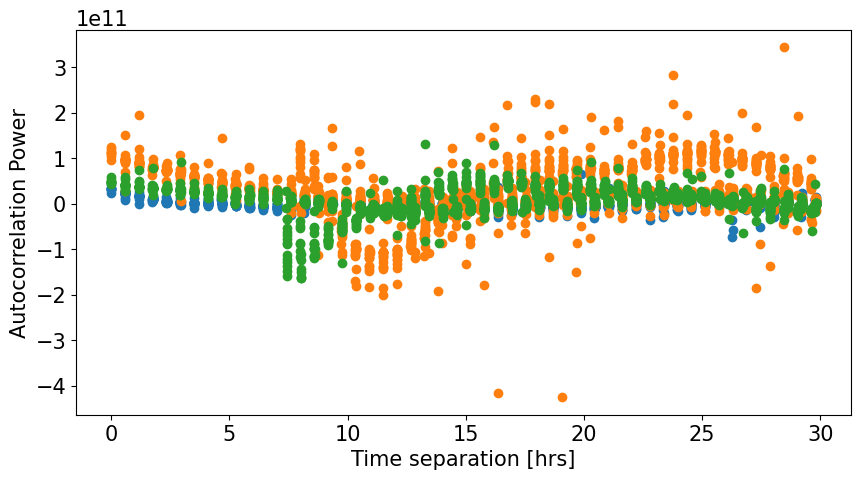

Full f=100MHz dataset measurement noise est.: 302390.1502397172


In [68]:
# Compute the ACF for each chunk to get an estimate of the measurement noise from dt=0
plt.figure(figsize=(10,5))

for i in range(3):
    time_rng = tt[(tt>time_stops[i]) & (tt<time_stops[i+1])]
    dat_rng = dd[(tt>time_stops[i]) & (tt<time_stops[i+1]),:][:,freq_index]
    dt = 5
    tot, wt = make_acf(dat=(dat_rng-dat_rng.mean()),t=time_rng,dt=dt,tmax=30*3600)
    
    # plot ACF here
    mm = wt > 0
    
    plt.plot(np.arange(len(tot))[mm]*dt/3600,(tot[mm]/wt[mm]),'o')
    print('Chunk',i,'measurement noise est.:',np.sqrt((tot[mm]/wt[mm])[0]))

plt.xlabel('Time separation [hrs]')
plt.ylabel('Autocorrelation Power')
plt.show()

# Full ACF
tot, wt = make_acf(dat=(dd[:,freq_index]-dd[:,freq_index].mean()),t=tt,dt=dt,tmax=5*3600)
mm = wt>0
print('Full f=100MHz dataset measurement noise est.:',np.sqrt((tot[mm]/wt[mm])[0]))

### Computing CROSS-Correlation of Short Power and Temperature

In [7]:
import test_short_interp
reload(test_short_interp)
# from test_short_interp import make_ccf
from test_short_interp import make_ccf_2sided
from test_short_interp import make_acf

#### Test the Cross-Correlation Function with Mock Datasets

2 offset sinc functions

In [8]:
def sincfunc(x,x0):
    return np.sin(x-x0)/(x-x0)

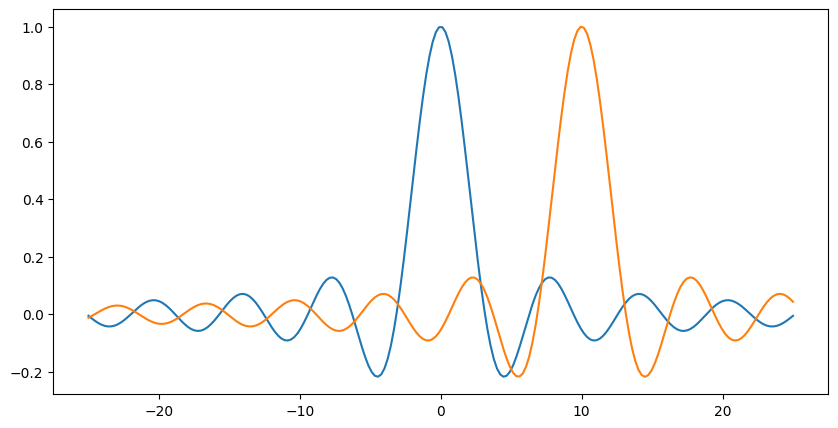

In [57]:
fig, ax = plt.subplots(figsize=(10,5))
x_range1,step = np.linspace(-25,25,220,retstep=True)
x_range2 = np.linspace(-25,25,220)
x_range2 = np.linspace(-25,25,220)
# x_range2 = np.linspace(-15,35,220)

testdat1 = sincfunc(x_range1,0)
testdat2 = sincfunc(x_range2,10)
# testdat2 = sincfunc(x_range2,0)
# print(60*step)

ax.plot(x_range1,testdat1)
ax.plot(x_range2,testdat2)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

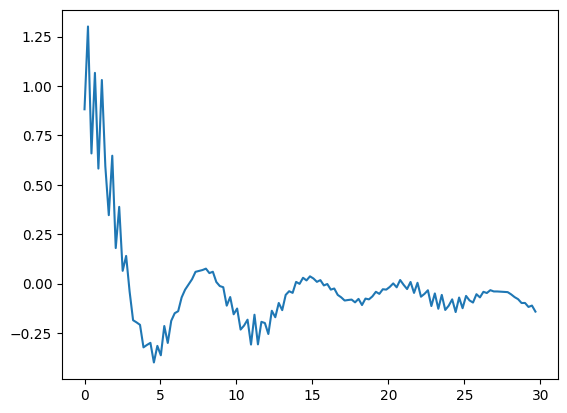

In [23]:
# Checking that ACF function has amplitude of 1 at dt=0 when you give it normalized data
tot, wt = make_acf(dat=(testdat2-testdat2.mean())/testdat2.std(),t=x_range2,dt=step,tmax=30)
mm = wt>0
plt.plot(np.arange(len(tot))[mm]*dt,tot[mm]/wt[mm])
plt.show()

On loop # 0
On loop # 100
On loop # 200


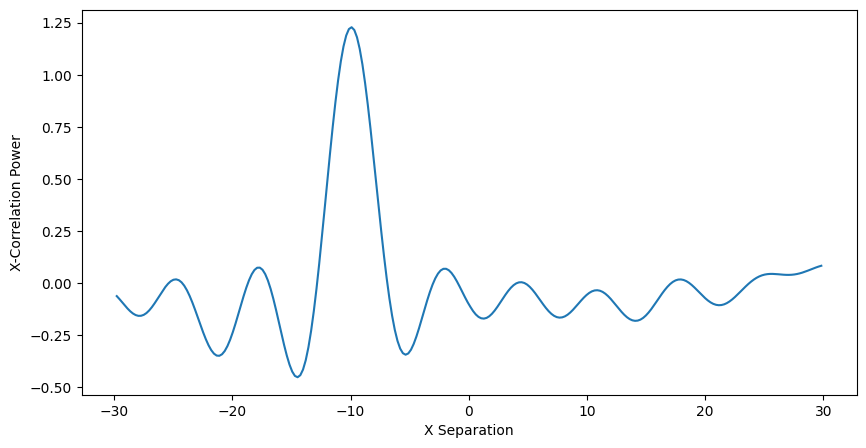

-9.908675799086808


In [24]:
dt=step
tot, wt, bins = make_ccf_2sided(dat1=(testdat1-testdat1.mean())/testdat1.std(),t1=x_range1,
                                dat2=(testdat2-testdat2.mean())/testdat2.std(),t2=x_range2,dt=dt,tmax=30)
mm = wt > 0
# dxrange = np.arange(len(tot))[mm]*dt
# print(bins)
plt.figure(figsize=(10,5))
plt.plot(bins[mm],tot[mm]/wt[mm])
plt.xlabel('X Separation',fontsize=10)
plt.ylabel('X-Correlation Power',fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

print(bins[mm][np.argmax(tot[mm]/wt[mm])])

#### Now X-Corr of Short Power and Temperature

In [32]:
# Temperature data
temp_type = '100NS_switch'
T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
temp_time = (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2
temp_mask = (temp_time>tmin)&(temp_time<tmax)


# Compute Short Power - Temperature Cross-Correlation
# Remember this is a x-corr with respect to time separation!!!!!!
dt=30
# tot, wt = make_ccf(dat1=(dd[:,freq_index]-dd[:,freq_index].mean()),t1=tt,dat2=(T_phys[f'temp_{temp_type}'][temp_mask]-T_phys[f'temp_{temp_type}'][temp_mask].mean()),t2=temp_time[temp_mask],dt=dt,tmax=30*3600)
# tot, wt = make_ccf(dat1=(dd[:,freq_index]-dd[:,freq_index].mean())/np.std(dd[:,freq_index]),t1=tt,dat2=(T_phys[f'temp_{temp_type}'][temp_mask]-T_phys[f'temp_{temp_type}'][temp_mask].mean())/np.std(T_phys[f'temp_{temp_type}'][temp_mask]),t2=temp_time[temp_mask],dt=dt,tmax=30*3600)
tot, wt, bins = make_ccf_2sided(dat1=(dd[:,freq_index]-np.nanmean(dd[:,freq_index]))/np.nanstd(dd[:,freq_index]),t1=tt,
                                dat2=(T_phys[f'temp_{temp_type}'][temp_mask]-np.nanmean(T_phys[f'temp_{temp_type}'][temp_mask]))/np.nanstd(T_phys[f'temp_{temp_type}'][temp_mask]),t2=temp_time[temp_mask],dt=dt,tmax=30*3600)
# syntax: make_ccf(dat1,t1,dat2,t2,dt,tmax)

On loop # 0
On loop # 100
On loop # 200
On loop # 300
On loop # 400
On loop # 500
On loop # 600
On loop # 700
On loop # 800
On loop # 900
On loop # 1000
On loop # 1100
On loop # 1200
On loop # 1300
On loop # 1400
On loop # 1500
On loop # 1600
On loop # 1700
On loop # 1800
On loop # 1900
On loop # 2000
On loop # 2100
On loop # 2200
On loop # 2300
On loop # 2400
On loop # 2500
On loop # 2600
On loop # 2700
On loop # 2800
On loop # 2900
On loop # 3000
On loop # 3100
On loop # 3200


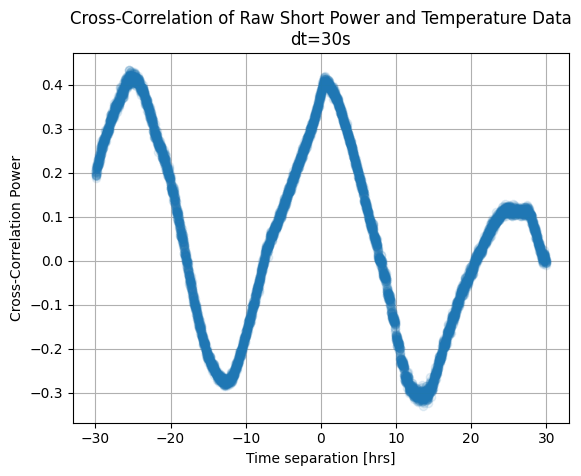

In [34]:
# Plot results
mm = (wt > 0)
dtrange = bins[mm]

plt.rcParams.update({'font.size': 10})
plt.plot(dtrange/3600,tot[mm]/wt[mm],'o',alpha=0.1)

plt.ylabel('Cross-Correlation Power')
# plt.ylabel('wt power (no wt division)')
plt.xlabel('Time separation [hrs]')
# plt.xlim(0,0.5)
# plt.xticks(fontsize=10)
# plt.yticks(fontsize=10)
# plt.legend()
plt.grid()
plt.title('Cross-Correlation of Raw Short Power and Temperature Data\ndt='+str(dt)+'s')
plt.show()

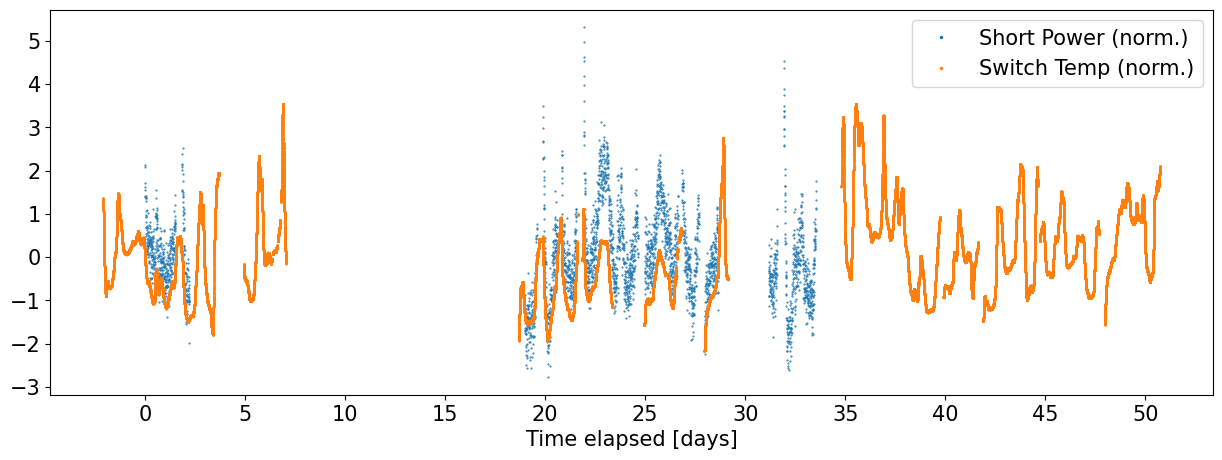

In [56]:
plt.figure(figsize=(15,5))
plt.plot((tt-tt[0])/3600/24,(dd[:,freq_index]-dd[:,freq_index].mean())/np.std(dd[:,freq_index]),ms=1,marker='.',ls='None',label='Short Power (norm.)')
plt.plot((temp_time[temp_mask]-tt[0])/3600/24,(T_phys[f'temp_{temp_type}'][temp_mask]-T_phys[f'temp_{temp_type}'][temp_mask].mean())/np.std(T_phys[f'temp_{temp_type}'][temp_mask]),ms=1,marker='.',ls='None',label='Switch Temp (norm.)')
plt.xlabel('Time elapsed [days]')
plt.xticks(np.linspace(0,50,11))
plt.legend(markerscale=3)
plt.show()

### Alternative X-Corr Algorithm

In [8]:
import test_short_interp
reload(test_short_interp)
from test_short_interp import make_ccf_2sided_binning

In [30]:
temp_type = '100NS_switch'
T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
temp_time = (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2
tmax=np.inf
tmin=0
temp_mask = (temp_time>tmin)&(temp_time<tmax)

dt=1800
dt_bins, ccf_tot = make_ccf_2sided_binning(dat1=(dd[:,freq_index]-np.nanmean(dd[:,freq_index])),t1=tt,
                                  dat2=(T_phys[f'temp_{temp_type}'][temp_mask]-np.nanmean(T_phys[f'temp_{temp_type}'][temp_mask])),t2=temp_time[temp_mask],
                                  dt=dt,tmax=30*3600)

# dt_bins, ccf_tot = make_ccf_2sided_binning(dat1=(T_phys[f'temp_{temp_type}'][temp_mask]-np.nanmean(T_phys[f'temp_{temp_type}'][temp_mask])),t1=temp_time[temp_mask],
#                                   dat2=(dd[:,freq_index]-np.nanmean(dd[:,freq_index])),t2=tt,
#                                   dt=dt,tmax=30*3600)


print(ccf_tot)

[ 0.25603584  0.32167692  0.38989342  0.45657636  0.52192243  0.58349506
  0.60669327  0.62574349  0.68263922  0.71975028  0.73335373  0.72986059
  0.70336504  0.66184752  0.60793239  0.53188106  0.4567672   0.40074356
  0.35689719  0.29317526  0.23788946  0.18881347  0.12910533  0.07171189
  0.00648552 -0.05589536 -0.12196735 -0.17085157 -0.22281726 -0.27865779
 -0.31614825 -0.34556441 -0.38168871 -0.39205797 -0.39127396 -0.40502658
 -0.40444445 -0.38806723 -0.35722733 -0.31037393 -0.25103452 -0.20379302
 -0.158403   -0.11211301 -0.06576785 -0.02751408  0.01691769  0.06071152
  0.08739674  0.11924409  0.15553812  0.19534772  0.24434138  0.29288906
  0.3501875   0.40712841  0.46456704  0.531769    0.59550008  0.66587515
  0.72393112  0.74278078  0.71851424  0.6775442   0.65706301  0.59843821
  0.55049916  0.49490616  0.43371551  0.37154227  0.30598952  0.24934383
  0.18728903  0.14886462  0.08076435  0.04784424 -0.01646338 -0.06216099
 -0.12154877 -0.19350492 -0.27393633 -0.35320507 -0

0.5


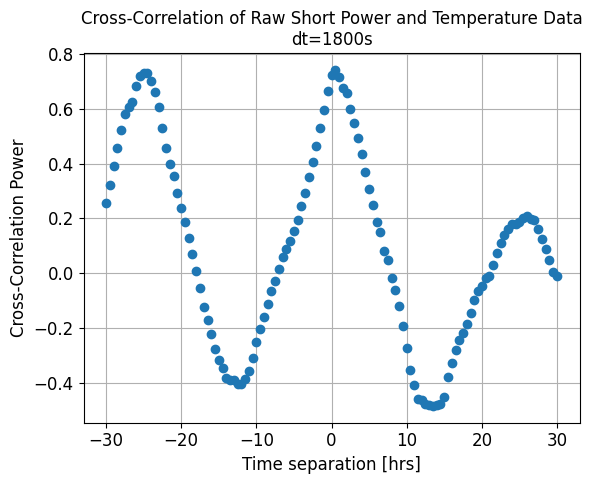

In [31]:
plt.rcParams.update({'font.size': 12})
plt.plot(dt_bins/3600,ccf_tot,'o')
print(dt_bins[np.argmax(ccf_tot)]/3600)

plt.rcParams.update({'font.size': 10})
plt.ylabel('Cross-Correlation Power')
plt.xlabel('Time separation [hrs]')
plt.grid()
plt.title('Cross-Correlation of Raw Short Power and Temperature Data\ndt='+str(dt)+'s')
plt.show()

#### Test: Running alternative CCF algorithm on twice the same dataset (<=>ACF)

[ 0.03236404  0.03919523  0.0936064   0.14165035  0.19963568  0.23973157
  0.26265654  0.29747272  0.26306226  0.28928829  0.30919319  0.3301296
  0.32740241  0.33956847  0.35470552  0.31769192  0.30187212  0.27762456
  0.30726292  0.28800773  0.28565092  0.2560201   0.20054178  0.18570632
  0.13581378  0.12345176  0.1098921   0.0817621   0.051996   -0.01375715
 -0.034408   -0.07984631 -0.07455517 -0.12602552 -0.09982343 -0.08948478
 -0.08669459 -0.04935882 -0.02361644  0.03488485  0.03837225  0.06245069
  0.07927077  0.1376656   0.13699481  0.12892441  0.15822288  0.18305611
  0.20941311  0.240013    0.3395563   0.38666817  0.39881597  0.44703821
  0.52131884  0.59080302  0.68077572  0.78885692  0.83826599  0.90333711
  1.00000393  0.90333711  0.83826599  0.78885692  0.68077572  0.59080302
  0.52131884  0.44703821  0.39881597  0.38666817  0.3395563   0.240013
  0.20941311  0.18305611  0.15822288  0.12892441  0.13699481  0.1376656
  0.07927077  0.06245069  0.03837225  0.03488485 -0.023

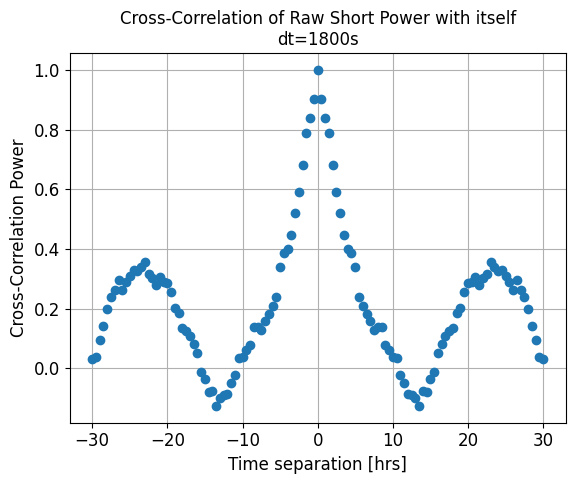

In [28]:
dt=1800
dt_bins, ccf_tot = make_ccf_2sided_binning(dat1=(dd[:,freq_index]-np.nanmean(dd[:,freq_index])),t1=tt,
                                  dat2=(dd[:,freq_index]-np.nanmean(dd[:,freq_index])),t2=tt,
                                  dt=dt,tmax=30*3600)
print(ccf_tot)

plt.rcParams.update({'font.size': 12})
plt.plot(dt_bins/3600,ccf_tot,'o')
print(np.max(ccf_tot))

plt.rcParams.update({'font.size': 10})
plt.ylabel('Cross-Correlation Power')
plt.xlabel('Time separation [hrs]')
plt.grid()
plt.title('Cross-Correlation of Raw Short Power with itself\ndt='+str(dt)+'s')
plt.show()

#### Test: Running alternative CCF algorithm on the shifted sinc function

[-0.12655056 -0.09845343 -0.06961332 -0.04128568 -0.01475101  0.00872591
  0.02794421  0.04182173  0.04945295  0.05016459  0.04356313  0.02956956
  0.00843925 -0.01923332 -0.05252344 -0.09019664 -0.13073984 -0.17240301
 -0.2132524  -0.25123617 -0.28426199 -0.31028436 -0.32739651 -0.33392078
 -0.32849016 -0.31011538 -0.27823386 -0.23273959 -0.17399496 -0.10282706
 -0.02051014  0.07126425  0.17042973  0.27460046  0.38114019  0.48724401
  0.59003077  0.68664198  0.7743422   0.85061519  0.91325122  0.96042185
  0.99074048  1.00330791  0.99774303  0.97419845  0.93336051  0.87643231
  0.80509848  0.72147075  0.62801503  0.52746216  0.42270683  0.31670001
  0.21234128  0.11237666  0.01930672 -0.06469189 -0.13782953 -0.19875045
 -0.24656306 -0.28085352 -0.30168247 -0.30956517 -0.30543546 -0.29059488
 -0.26664906 -0.23543417 -0.19893688 -0.15921161 -0.11829845 -0.07814508
 -0.04053535 -0.00702686  0.02110054  0.04288364  0.05770076  0.06528175
  0.0657026   0.05936504  0.0469624   0.02943365  0

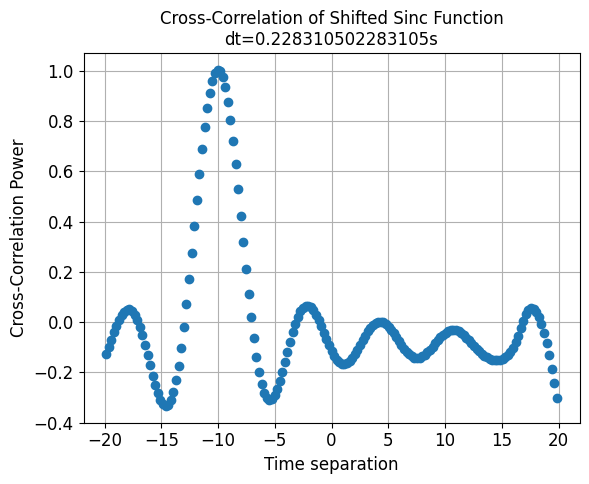

In [60]:
dt=step
dt_bins, ccf_tot = make_ccf_2sided_binning(dat1=testdat1-np.nanmean(testdat1),t1=x_range1,
                                  dat2=testdat2-np.nanmean(testdat2),t2=x_range2,
                                  dt=dt,tmax=20)
print(ccf_tot)

plt.plot(dt_bins,ccf_tot,'o')
print(np.max(ccf_tot))

plt.rcParams.update({'font.size': 10})
plt.ylabel('Cross-Correlation Power')
plt.xlabel('Time separation')
plt.grid()
plt.title('Cross-Correlation of Shifted Sinc Function\ndt='+str(dt)+'s')
plt.show()

### Improving the binning scheme for the alternative ACF algorithm

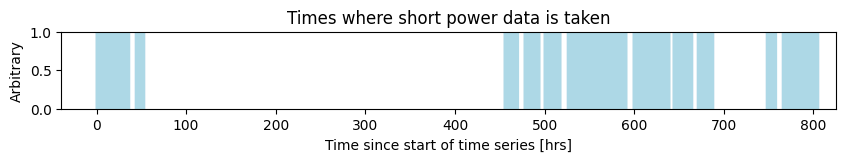

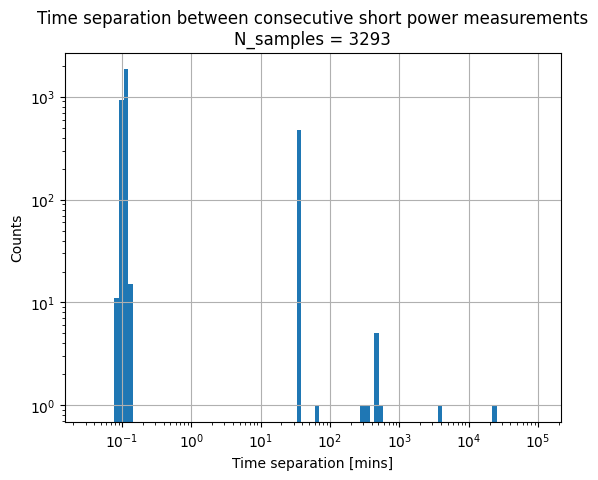

6.359218913295012


In [17]:
# Figuring out the typical spacing between calibrator cycles
plt.figure(figsize=(10,1))
plt.rcParams.update({'font.size': 10})
for i in range(len(tt)):
    plt.axvline((tt[i]-tt[0])/3600,color='lightblue') # in hours
plt.xlabel('Time since start of time series [hrs]')
plt.ylabel('Arbitrary')
plt.title('Times where short power data is taken')
plt.show()

# Make a histogram since this plot is telling us nothing useful about short term variations
caltdiffs = np.diff(tt)/60 # in mins
plt.rcParams.update({'font.size': 10})
n, bins, _ = plt.hist(caltdiffs,bins=np.logspace(-1.5,5,100),log=True)
# plt.yscale('log')
plt.xscale('log')
plt.title(f'Time separation between consecutive short power measurements\nN_samples = {len(caltdiffs)}')
plt.xlabel('Time separation [mins]')
plt.ylabel('Counts')
plt.grid()
plt.show()

print(bins[np.argmax(n)]*60)

In [60]:
# Remove the sub-minute spacing: those gaps are from measurements taken within the same cal cycle
bin_mids = np.array([np.mean([bins[i],bins[i+1]]) for i in range(len(bins)-1)])
# print(bin_mids)
# print(bins)
# Find the center of the bin with most counts above 1 minute
supmin_n = n[bin_mids>=1]
supmin_binmids = bin_mids[bin_mids>=1]
print(supmin_binmids[np.argmax(supmin_n)])

35.831902425988844


In [69]:
# Compute the actual mean and std of the diffs that went into that bin
binleft = bins[bins>=1][np.argmax(n[bins[:-1]>=1])]
binright = bins[bins>=1][np.argmax(n[bins[:-1]>=1])+1]
print(binleft,binright)

diffs_in_bin = caltdiffs[(caltdiffs >= binleft) & (caltdiffs < binright)]
print(np.mean(diffs_in_bin),np.std(diffs_in_bin))

# Extract the >1 minute separations that do not fit in the majority bin
caltdiffs_supmin = caltdiffs[caltdiffs>=1]
diffs_not_inbins_supmin = caltdiffs_supmin[(caltdiffs_supmin < binleft) | (caltdiffs_supmin >= binright)]
print(diffs_not_inbins_supmin)
print(len(diffs_not_inbins_supmin))
print(diffs_not_inbins_supmin/np.mean(diffs_in_bin)) # are they multiples of 34.45mins?

33.12851891487237 38.535285937105314
34.446720047328206 0.0898003127266612
[  455.16109576 24188.11429762   479.25579485   349.92529548
    69.48019799   525.05606748   494.48085438   314.93872018
   444.75228694  3645.36699538   490.59240323]
11
[ 13.21348143 702.18918563  13.91295874  10.15845035   2.01703378
  15.24255624  14.3549474    9.14277817  12.91131017 105.82624384
  14.24206434]


In [26]:
import test_short_interp
reload(test_short_interp)
from test_short_interp import make_ccf_2sided_advanced_binning

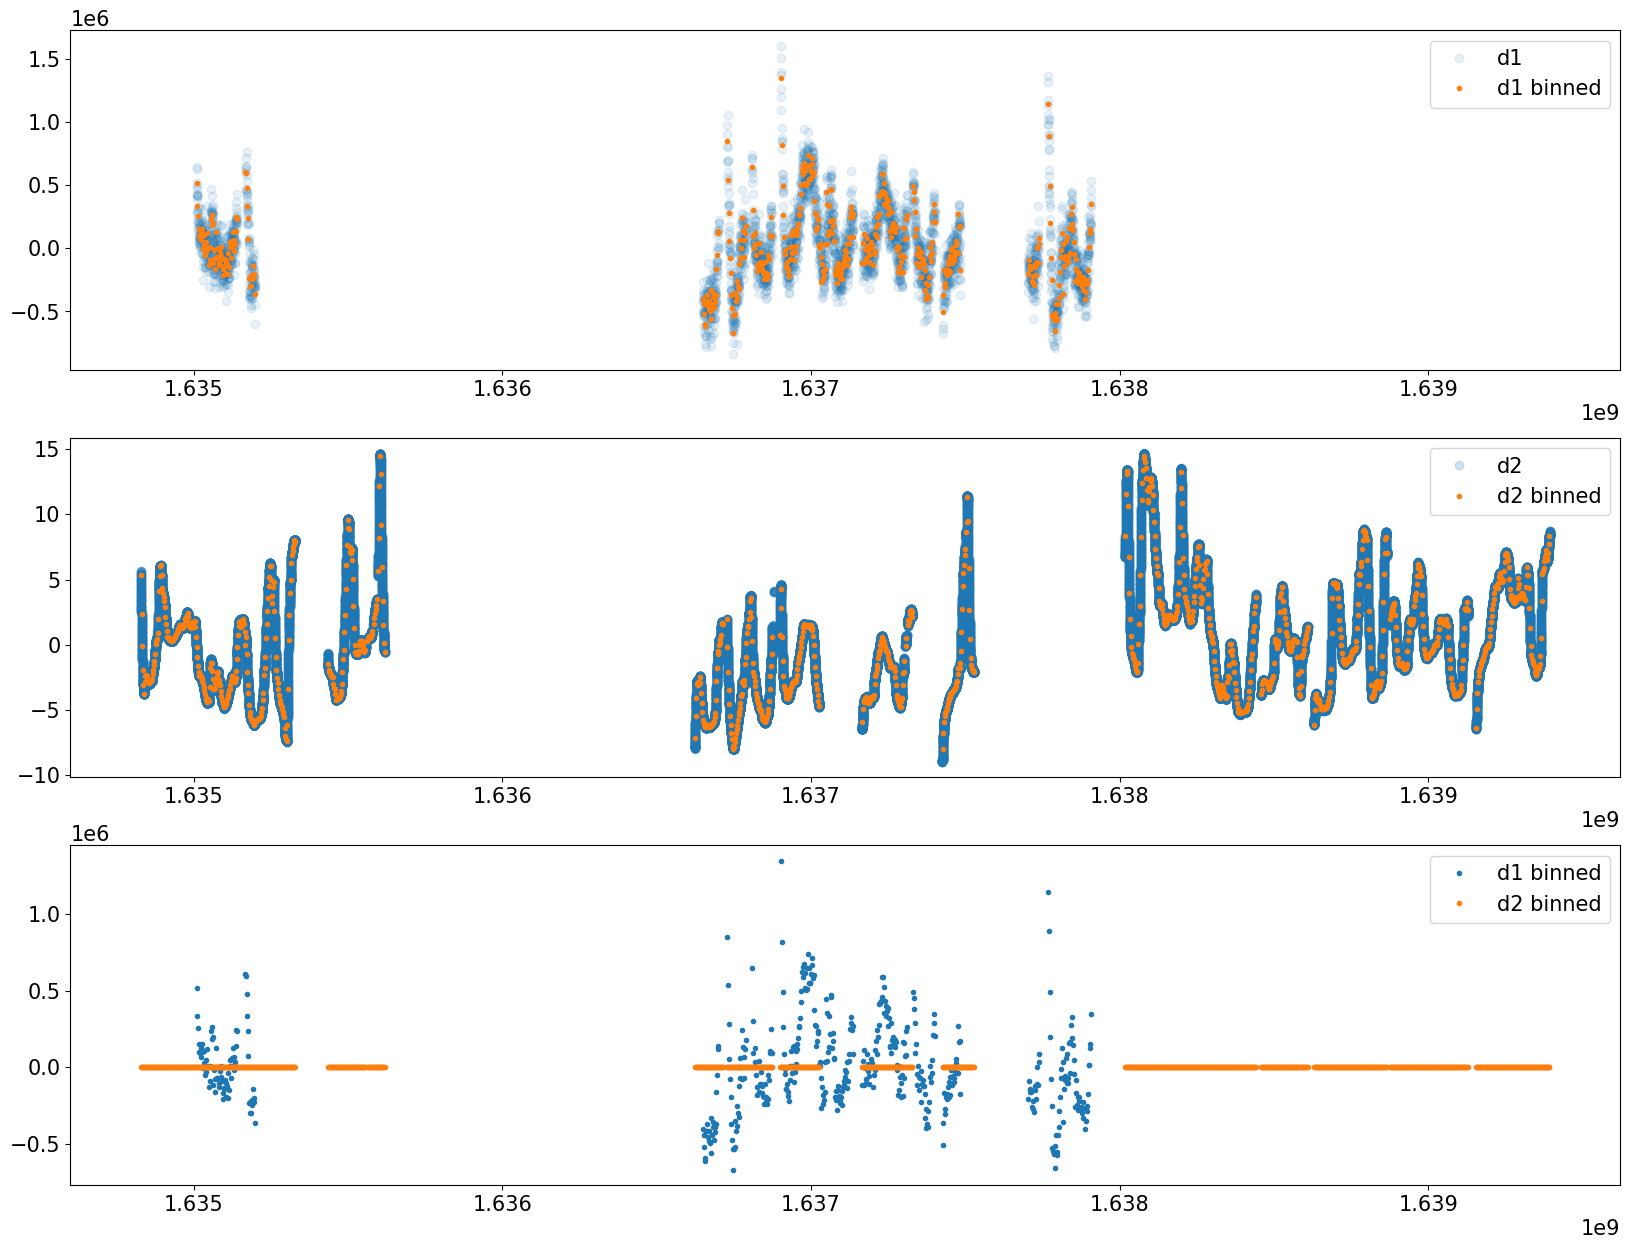

In [25]:
# Testing the new binning scheme
temp_type = '100NS_switch'
T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
temp_time = (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2
tmax=np.inf
tmin=0
temp_mask = (temp_time>tmin)&(temp_time<tmax)

'''TO GET THE PLOTS, UNCOMMENT THE PLOTTING CODE IN make_ccf_2sided_advanced_binning() in test_short_interp.py'''
make_ccf_2sided_advanced_binning(dat1=(dd[:,freq_index]-np.nanmean(dd[:,freq_index])),t1=tt,
                                  dat2=(T_phys[f'temp_{temp_type}'][temp_mask]-np.nanmean(T_phys[f'temp_{temp_type}'][temp_mask])),t2=temp_time[temp_mask],
                                tmax=30*3600)

In [18]:
# Run full algorithm
dt_bins_advbin, ccf_tot_advbin = make_ccf_2sided_advanced_binning(dat1=(dd[:,freq_index]-np.nanmean(dd[:,freq_index])),t1=tt,
                                  dat2=(T_switch[f'temp_{temp_type}'][temp_mask]-np.nanmean(T_switch[f'temp_{temp_type}'][temp_mask])),t2=systime_switch[temp_mask],
                                    tmax=30*3600)

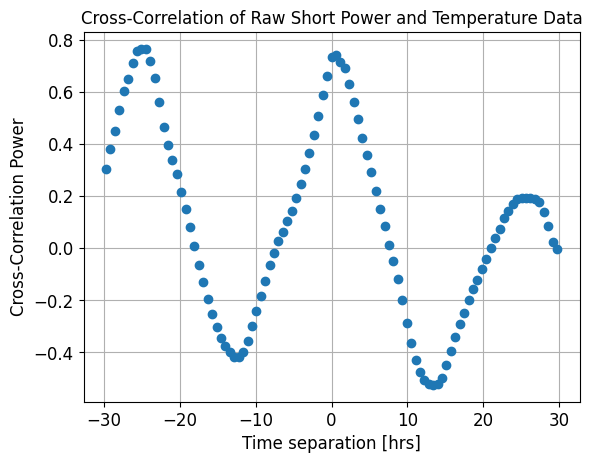

In [19]:
plt.rcParams.update({'font.size': 12})
plt.plot(dt_bins_advbin/3600,ccf_tot_advbin,'o')
# print(dt_bins_advbin/3600)
plt.rcParams.update({'font.size': 10})
plt.ylabel('Cross-Correlation Power')
plt.xlabel('Time separation [hrs]')
plt.grid()
plt.title('Cross-Correlation of Raw Short Power and Temperature Data')
plt.show()

## Cross-correlation between other calibrators and temperature

100 Ohm, 50 Ohm

noise source? -- previously investigated by Fernando I think

In [6]:
import test_short_interp
reload(test_short_interp)
from test_short_interp import make_ccf_2sided_advanced_binning

### 50 $\Omega$

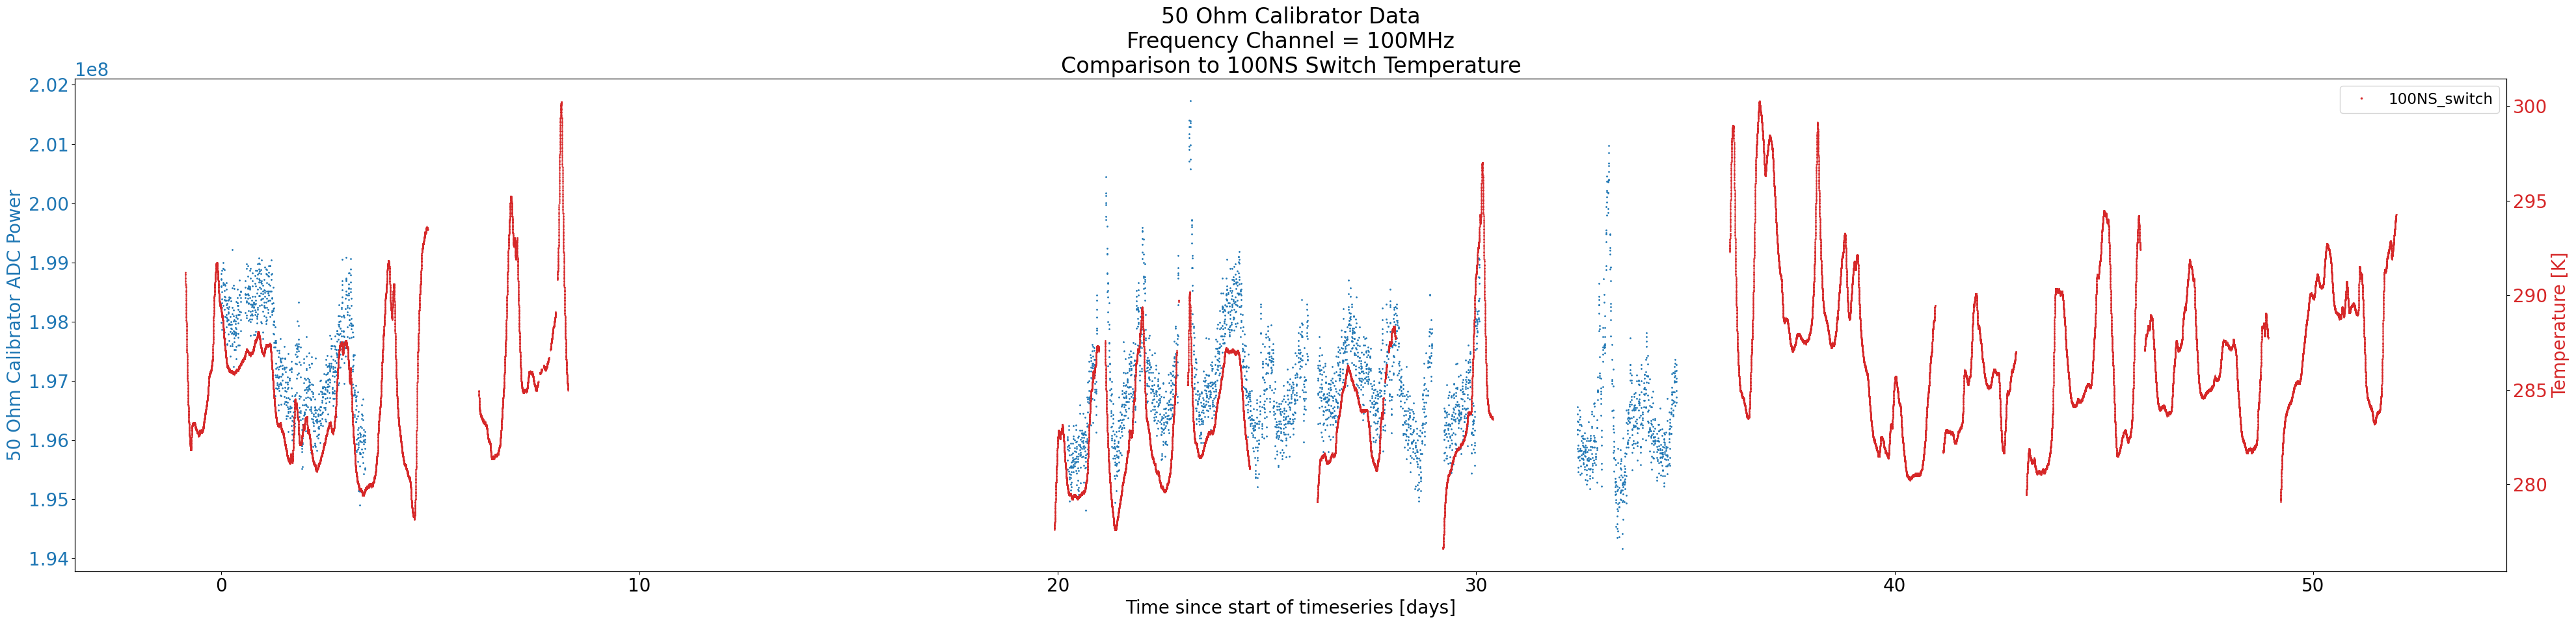

In [7]:
# Importing system temperature to check correlations between temperature variations and calibrator power variations
from data import get_temperatures, interpolate_temperature

# path to temperature directories (2021 only)
plt.rcParams.update({'font.size': 20})
path2dir = f'/project/s/sievers/prizm/marion2022/prizm-{instrument[:-3]}/data_{instrument}/temperatures'
# temp_type = 'ambient'
# T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
# T_amb, systime_amb, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, tt)
temp_type = '100NS_switch'
T_switch = get_temperatures(instrument, path2dir, temp_type=temp_type)
# T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, tt)
systime_switch = (T_switch['time_sys_start'] + T_switch['time_sys_stop']) / 2
temp_mask = (systime_switch>tmin)&(systime_switch<tmax)
# -------------------------------------------
fig, ax1 = plt.subplots(figsize=(40,10))

color = 'tab:blue'
ax1.set_xlabel('Time since start of timeseries [days]')
ax1.set_ylabel('50 Ohm Calibrator ADC Power',color=color)
# ax1.plot(t, data1, color=color)
ax1.plot((t_50-t_50[0])/3600/24,dat_50[:,freq_index],color=color,label='Calibrator data',ms=2,marker='.',ls='None')

ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Temperature [K]', color=color)  # we already handled the x-label with ax1
# ax2.plot((systime_amb-tt[0])/3600/24, T_amb, color=color,ls='none',marker='.',label='ambient')
ax2.plot((systime_switch-t_50[0])/3600/24, T_switch[f'temp_{temp_type}'], color=color,ms=1,ls='none',marker='.',label='100NS_switch')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(markerscale=3,fontsize='small')

plt.title('50 Ohm Calibrator Data\nFrequency Channel = '+str(freq)+'MHz\nComparison to 100NS Switch Temperature')
fig.tight_layout()  # otherwise the right y-label is slightly clipped

plt.show()

In [36]:
# CCF
# Temperature data
# temp_type = '100NS_switch'
# T_switch = get_temperatures(instrument, path2dir, temp_type=temp_type)
# systime_switch = (T_switch['time_sys_start'] + T_switch['time_sys_stop']) / 2
# temp_mask = (systime_switch>tmin)&(systime_switch<tmax)

dt_bins_advbin, ccf_tot_advbin = make_ccf_2sided_advanced_binning(dat1=(dat_50[:,freq_index]-np.nanmean(dat_50[:,freq_index])),t1=t_50,
                                  dat2=(T_switch[f'temp_{temp_type}'][temp_mask]-np.nanmean(T_switch[f'temp_{temp_type}'][temp_mask])),t2=systime_switch[temp_mask],
                                    tmax=30*3600)

70.0


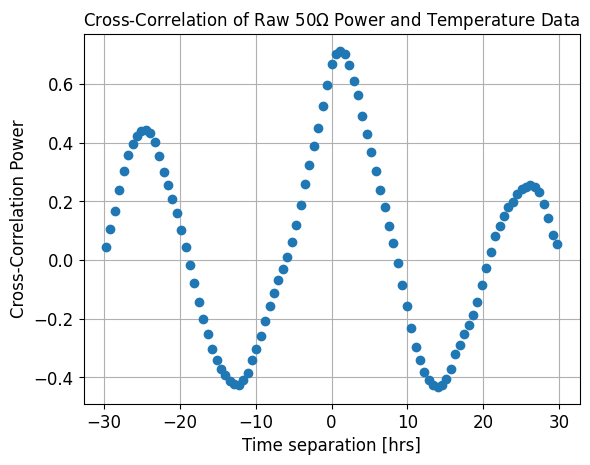

In [37]:
plt.rcParams.update({'font.size': 12})
plt.plot(dt_bins_advbin/3600,ccf_tot_advbin,'o')
print(dt_bins_advbin[np.argmax(ccf_tot_advbin)]/60)
# print(dt_bins_advbin/3600)
plt.rcParams.update({'font.size': 10})
plt.ylabel('Cross-Correlation Power')
plt.xlabel('Time separation [hrs]')
plt.grid()
plt.title('Cross-Correlation of Raw 50$\Omega$ Power and Temperature Data')
plt.show()

### $100\Omega$

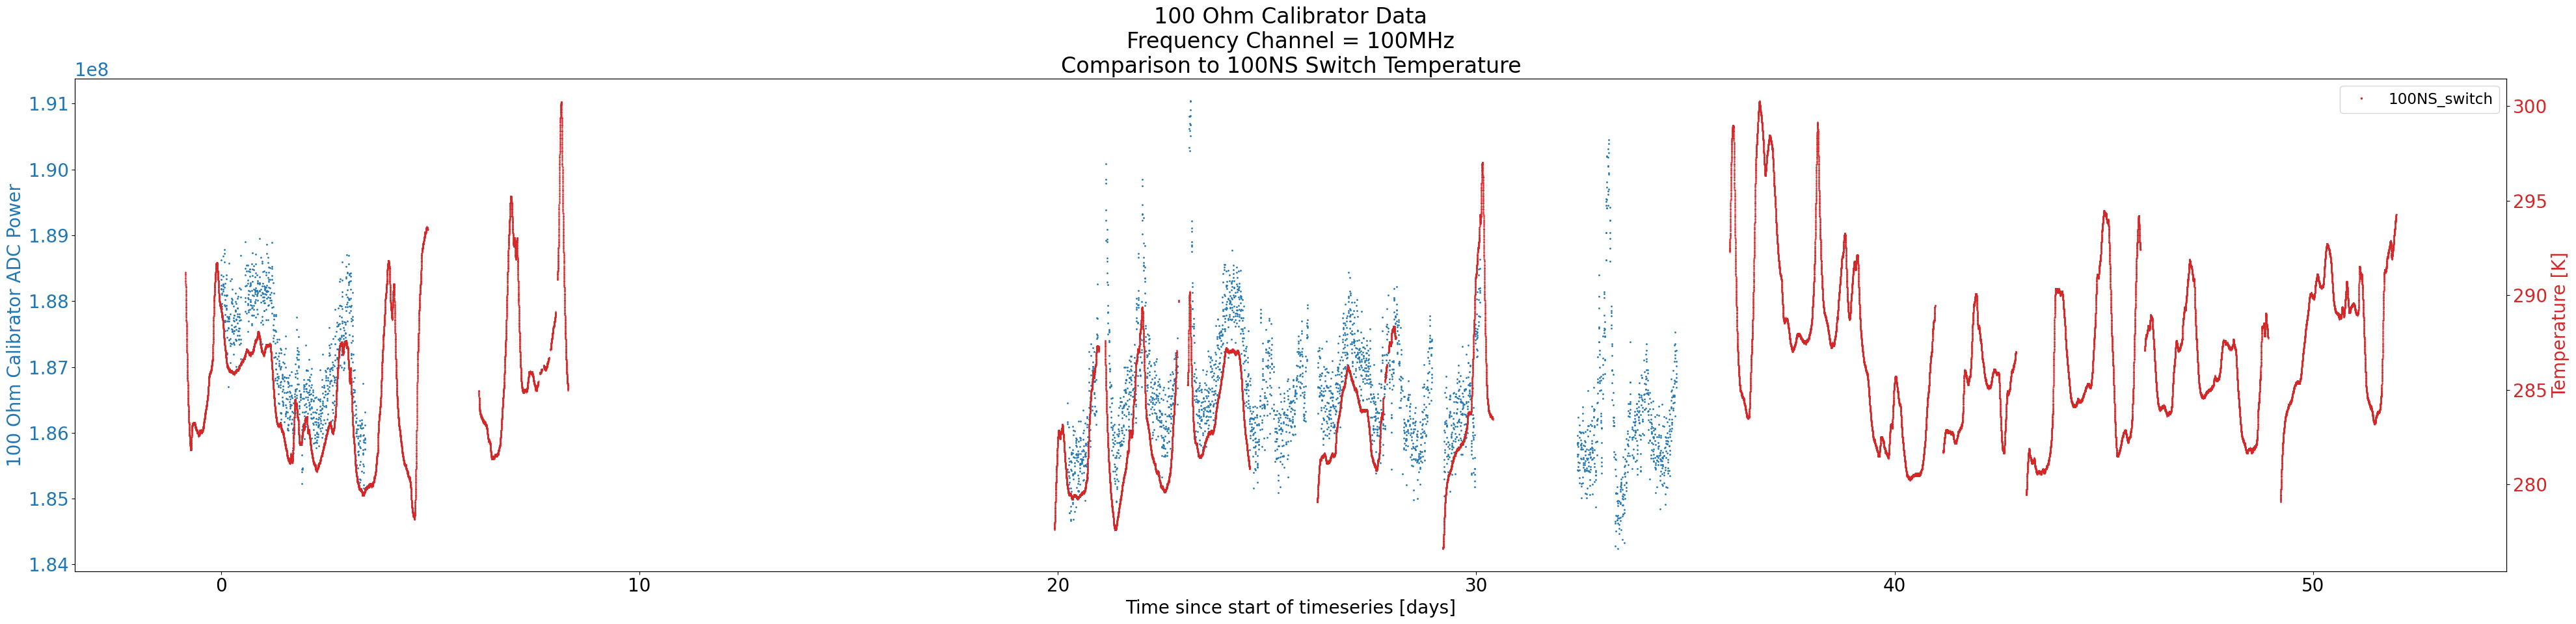

In [32]:
# Importing system temperature to check correlations between temperature variations and calibrator power variations
from data import get_temperatures, interpolate_temperature

# path to temperature directories (2021 only)
plt.rcParams.update({'font.size': 20})
path2dir = f'/project/s/sievers/prizm/marion2022/prizm-{instrument[:-3]}/data_{instrument}/temperatures'
# temp_type = 'ambient'
# T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
# T_amb, systime_amb, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, tt)
temp_type = '100NS_switch'
T_switch = get_temperatures(instrument, path2dir, temp_type=temp_type)
# T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, tt)
systime_switch = (T_switch['time_sys_start'] + T_switch['time_sys_stop']) / 2
temp_mask = (systime_switch>tmin)&(systime_switch<tmax)
# -------------------------------------------
fig, ax1 = plt.subplots(figsize=(40,10))

color = 'tab:blue'
ax1.set_xlabel('Time since start of timeseries [days]')
ax1.set_ylabel('100 Ohm Calibrator ADC Power',color=color)
# ax1.plot(t, data1, color=color)
ax1.plot((t_100-t_100[0])/3600/24,dat_100[:,freq_index],color=color,label='Calibrator data',ms=2,marker='.',ls='None')
# ax1.plot((tt-t_100[0])/3600/24,dd[:,freq_index],color='orange',label='Calibrator data short',ms=2,marker='.',ls='None')

ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Temperature [K]', color=color)  # we already handled the x-label with ax1
# ax2.plot((systime_amb-tt[0])/3600/24, T_amb, color=color,ls='none',marker='.',label='ambient')
ax2.plot((systime_switch-t_100[0])/3600/24, T_switch[f'temp_{temp_type}'], color=color,ms=1,ls='none',marker='.',label='100NS_switch')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(markerscale=3,fontsize='small')

plt.title('100 Ohm Calibrator Data\nFrequency Channel = '+str(freq)+'MHz\nComparison to 100NS Switch Temperature')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
# plt.savefig()

plt.show()

In [33]:
# CCF
# Temperature data
# temp_type = '100NS_switch'
# T_switch = get_temperatures(instrument, path2dir, temp_type=temp_type)
# systime_switch = (T_switch['time_sys_start'] + T_switch['time_sys_stop']) / 2
# temp_mask = (systime_switch>tmin)&(systime_switch<tmax)

dt_bins_advbin, ccf_tot_advbin = make_ccf_2sided_advanced_binning(dat1=(dat_100[:,freq_index]-np.nanmean(dat_100[:,freq_index])),t1=t_100,
                                  dat2=(T_switch[f'temp_{temp_type}'][temp_mask]-np.nanmean(T_switch[f'temp_{temp_type}'][temp_mask])),t2=systime_switch[temp_mask],
                                    tmax=30*3600)

105.0


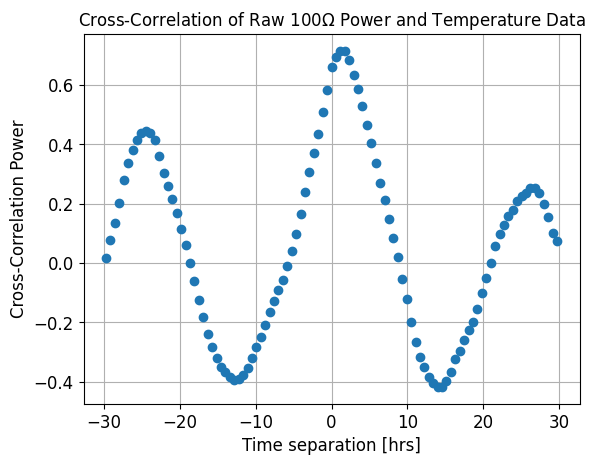

In [35]:
plt.rcParams.update({'font.size': 12})
plt.plot(dt_bins_advbin/3600,ccf_tot_advbin,'o')
print(dt_bins_advbin[np.argmax(ccf_tot_advbin)]/60)
# print(dt_bins_advbin/3600)
plt.rcParams.update({'font.size': 10})
plt.ylabel('Cross-Correlation Power')
plt.xlabel('Time separation [hrs]')
plt.grid()
plt.title('Cross-Correlation of Raw 100$\Omega$ Power and Temperature Data')
plt.show()

In [ ]:
# WIP